In [1]:
%pip install tqdm -q

Note: you may need to restart the kernel to use updated packages.


# Import all libraries we will need

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Read the files with pandas

In [4]:
# Load the CSV files into pandas DataFrames
df_stores = pd.read_csv('/Users/dianaterraza/Desktop/Data/stores.csv')
df_items = pd.read_csv('/Users/dianaterraza/Desktop/Data/items.csv')
df_transactions = pd.read_csv('/Users/dianaterraza/Desktop/Data/transactions.csv')
df_oil = pd.read_csv('/Users/dianaterraza/Desktop/Data/oil.csv')
df_holidays_events = pd.read_csv('/Users/dianaterraza/Desktop/Data/holidays_events.csv')
df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')
df_test = pd.read_csv('/Users/dianaterraza/Desktop/Data/test.csv')

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_3165/2255240867.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv')


In [6]:
# Let's filter the data for one store and one item to keep it simple
store_ids = [1]
item_ids = [96995]
#Select data January-March 2014 period
start_date = '2014-01-01'
end_date = '2014-03-31'


# Initialize an empty list to hold filtered chunks
filtered_chunks = []

# Define the chunk size (number of rows per chunk)
chunk_size = 10 ** 6  # Adjust based on your system's memory capacity

# Read the CSV file in chunks
for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):
    # Filter the chunk for the desired store IDs
    chunk_filtered = chunk[(chunk['store_nbr'].isin(store_ids)) &
                            (chunk['date'] >= start_date) &
                            (chunk['date'] <= end_date)]
    # Append the filtered chunk to the list
    filtered_chunks.append(chunk_filtered)
    # Optional: Delete the chunk to free up memory
    del chunk

# Concatenate all filtered chunks into a single DataFrame
df_filtered = pd.concat(filtered_chunks, ignore_index=True)

# Clean up to free memory
del filtered_chunks

/var/folders/p6/1v6w0vgj3d951b4r8sgj0lgw0000gn/T/ipykernel_3165/3230739008.py:16: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv('/Users/dianaterraza/Desktop/Data/train.csv', chunksize=chunk_size):


# Prepare data

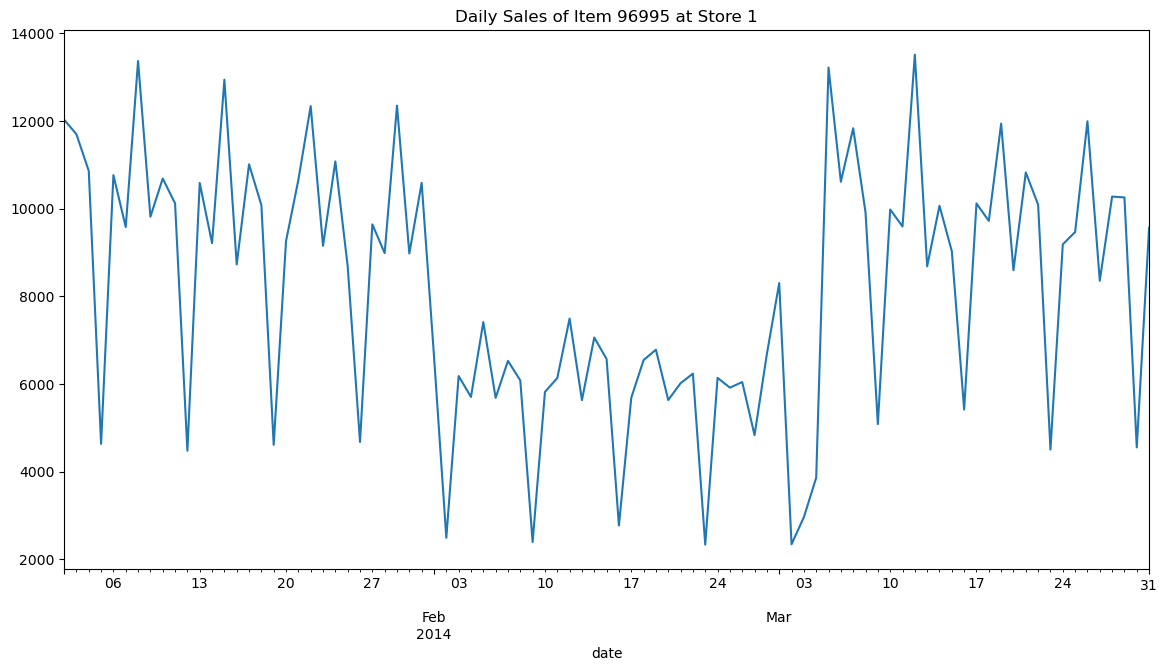

In [7]:
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Group by date and aggregate sales
df_filtered = df_filtered.groupby('date').sum()['unit_sales'].reset_index()

# Fill missing dates with zero sales
df_filtered.set_index('date', inplace=True)
df_filtered = df_filtered.asfreq('D').fillna(0)

# Visualize sales data
plt.figure(figsize=(14, 7))
df_filtered['unit_sales'].plot()
plt.title('Daily Sales of Item 96995 at Store 1')
plt.show()

# Preprocessing the Data for LSTM

In [9]:
# Normalize the data using Min-Max scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_filtered['unit_sales'] = scaler.fit_transform(df_filtered[['unit_sales']])

# Create sequences of data for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Set sequence length (e.g., past 30 days of sales)
seq_length = 30

# Create sequences
data = df_filtered['unit_sales'].values
X, y = create_sequences(data, seq_length)

# Split into training and testing sets (80% training, 20% testing)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape the data to be [samples, time steps, features] for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM model

In [10]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.2663 - val_loss: 0.4401
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2530 - val_loss: 0.4194
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2408 - val_loss: 0.4013
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.2292 - val_loss: 0.3846
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.2182 - val_loss: 0.3674
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2106 - val_loss: 0.3478
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1982 - val_loss: 0.3284
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1907 - val_loss: 0.3082
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1800 - val_loss: 0.2875
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.1703 - val_loss: 0.2686
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.1595 - val_loss: 0.2490
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1479 - val_loss: 0.2282
Epoch 13/20
1/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


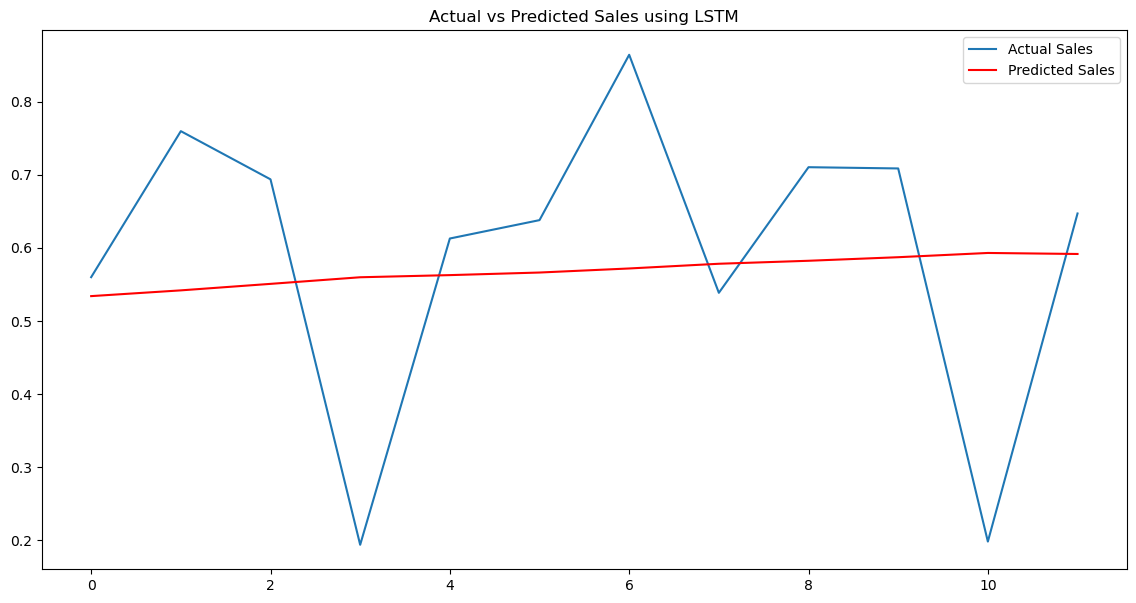

In [11]:
# Make predictions
predictions = model.predict(X_test)

# Inverse scale the predictions and actual values
predictions = scaler.inverse_transform(predictions)
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions vs actual values
plt.figure(figsize=(14, 7))
plt.plot(y_test_scaled, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales using LSTM')
plt.legend()
plt.show()
